In [92]:
import os, sys
from importlib import reload
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/camp/home/tootoos/working/tootoos/conda-envs/numpyro-env/lib/python3.10/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['split']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [4]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()

'/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/model-fitting'

In [8]:
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"
os.environ["OB_IO_CONN_MODELS"] = git_path + "/ob_io_conn_models"

In [11]:
import driver; reload(driver)
X0, Y0 = driver.get_data(full=True)

Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p


In [95]:
import split; reload(split)
df = split.data_to_df(X0, split.IoType.INPUT)

In [97]:
Sampler = split.TrialsSampler(n_test=2, n_train=3, which_odours=[2,3,5,7])
si = Sampler.generate(df).materialize(df)

In [98]:
X = split.df2mat(si.val)
X.shape

(148, 4)

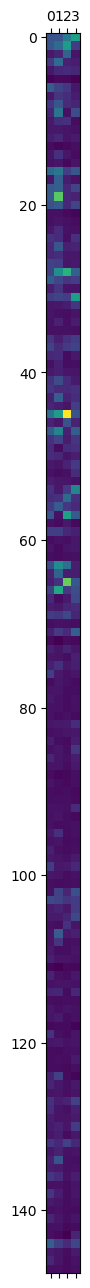

In [99]:
plt.matshow(X)

In [65]:
trials_ss = trials.materialize(df)

In [60]:
trials_ss.val.head()

,experiment,id_in_exp,glob_id,odour,trial,response,type
2,0,0,0,0,2,14.932942,input
5,0,0,0,1,2,9.954973,input
6,0,0,0,2,0,31.256591,input
9,0,0,0,3,0,38.064275,input
14,0,0,0,4,2,18.415243,input


In [61]:
X = split.df2mat(trials_ss.val)

In [56]:
X.shape

(148, 48)

In [48]:
trials_ss.val["neuron"].nunique()

36